In [36]:
import os, random, numpy as np, librosa
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [31]:
BASE = "/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-2sec/for-2seconds/training"
REAL_DIR = os.path.join(BASE, "real")
FAKE_DIR = os.path.join(BASE, "fake")

real_files = os.listdir(REAL_DIR)
fake_files = os.listdir(FAKE_DIR)

print(f"Real files: {len(real_files)}")
print(f"Fake files: {len(fake_files)}")
print(f"Sample real: {real_files[0]}")
print(f"Sample fake: {fake_files[0]}")

Real files: 6978
Fake files: 6978
Sample real: file26954.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav
Sample fake: file14641.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav


In [32]:
from tqdm.notebook import tqdm

N = 3000  # 3000 per class

real_sample = random.sample(real_files, N)
fake_sample = random.sample(fake_files, N)

all_paths  = [os.path.join(REAL_DIR, f) for f in real_sample] + \
             [os.path.join(FAKE_DIR, f) for f in fake_sample]
all_labels = [0] * N + [1] * N  # 0=real, 1=fake

def extract_melspec(path, sr=16000, n_mels=64, duration=2.0):
    try:
        y, _ = librosa.load(path, sr=sr, mono=True, duration=duration)
        target = int(sr * duration)
        if len(y) < target:
            y = np.pad(y, (0, target - len(y)))
        else:
            y = y[:target]
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        return mel_db.astype(np.float32)
    except:
        return None

X, y_labels = [], []
failed = 0

for path, label in tqdm(zip(all_paths, all_labels), total=len(all_paths)):
    feat = extract_melspec(path)
    if feat is not None:
        X.append(feat)
        y_labels.append(label)
    else:
        failed += 1

X = np.array(X)
y_labels = np.array(y_labels)
print(f"Done! X shape: {X.shape}, Failed: {failed}")

  0%|          | 0/6000 [00:00<?, ?it/s]

Done! X shape: (6000, 64, 63), Failed: 0


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, stratify=y_labels, random_state=42
)

class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).unsqueeze(1)  # (N, 1, 64, 63)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = AudioDataset(X_train, y_train)
test_ds  = AudioDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64)

print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")
print(f"Input shape: {train_ds[0][0].shape}")

Train: 4800 | Test: 1200
Input shape: torch.Size([1, 64, 63])


In [38]:
class AudioCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 1)
        )
    def forward(self, x): return self.net(x).squeeze(1)

model = AudioCNN().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model ready. Parameters: {total_params:,}")
print(f"Running on: {device}")

Model ready. Parameters: 617,921
Running on: cuda


In [39]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 20
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += ((torch.sigmoid(preds) > 0.5).float() == yb).sum().item()
        total += len(yb)
    
    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    acc = correct / total * 100
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")

Epoch  1/20 | Loss: 0.3225 | Train Acc: 84.54%
Epoch  2/20 | Loss: 0.1406 | Train Acc: 94.50%
Epoch  3/20 | Loss: 0.0812 | Train Acc: 97.08%
Epoch  4/20 | Loss: 0.0533 | Train Acc: 98.33%
Epoch  5/20 | Loss: 0.0328 | Train Acc: 98.90%
Epoch  6/20 | Loss: 0.0202 | Train Acc: 99.40%
Epoch  7/20 | Loss: 0.0142 | Train Acc: 99.67%
Epoch  8/20 | Loss: 0.0087 | Train Acc: 99.71%
Epoch  9/20 | Loss: 0.0119 | Train Acc: 99.67%
Epoch 10/20 | Loss: 0.0093 | Train Acc: 99.73%
Epoch 11/20 | Loss: 0.0042 | Train Acc: 99.88%
Epoch 12/20 | Loss: 0.0023 | Train Acc: 99.98%
Epoch 13/20 | Loss: 0.0034 | Train Acc: 99.85%
Epoch 14/20 | Loss: 0.0014 | Train Acc: 99.98%
Epoch 15/20 | Loss: 0.0015 | Train Acc: 99.98%
Epoch 16/20 | Loss: 0.0011 | Train Acc: 99.98%
Epoch 17/20 | Loss: 0.0013 | Train Acc: 100.00%
Epoch 18/20 | Loss: 0.0009 | Train Acc: 99.98%
Epoch 19/20 | Loss: 0.0020 | Train Acc: 99.96%
Epoch 20/20 | Loss: 0.0043 | Train Acc: 99.85%


  Accuracy:       99.58%   (need ≥ 80%)
  F1 Score:       99.58%   (need ≥ 80%)
  EER:            0.50%    (need ≤ 12%)
  Real Accuracy:  99.67%   (need ≥ 75%)
  Fake Accuracy:  99.50%   (need ≥ 75%)


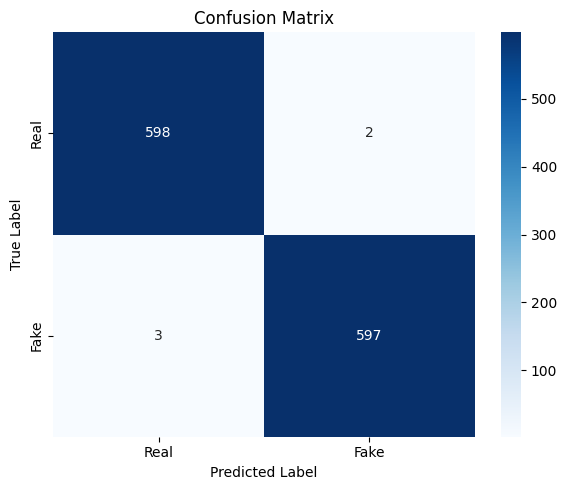

Confusion matrix saved!


In [40]:
model.eval()
all_preds, all_scores, all_true = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        scores = torch.sigmoid(model(xb)).cpu().numpy()
        preds  = (scores > 0.5).astype(int)
        all_scores.extend(scores)
        all_preds.extend(preds)
        all_true.extend(yb.numpy().astype(int))

all_scores = np.array(all_scores)
all_preds  = np.array(all_preds)
all_true   = np.array(all_true)

# Metrics
acc    = accuracy_score(all_true, all_preds) * 100
f1     = f1_score(all_true, all_preds) * 100
cm     = confusion_matrix(all_true, all_preds)

# Per class accuracy
real_acc = cm[0,0] / cm[0].sum() * 100
fake_acc = cm[1,1] / cm[1].sum() * 100

# EER
fpr, tpr, _ = roc_curve(all_true, all_scores)
fnr = 1 - tpr
eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.) * 100

print("="*45)
print(f"  Accuracy:       {acc:.2f}%   (need ≥ 80%)")
print(f"  F1 Score:       {f1:.2f}%   (need ≥ 80%)")
print(f"  EER:            {eer:.2f}%    (need ≤ 12%)")
print(f"  Real Accuracy:  {real_acc:.2f}%   (need ≥ 75%)")
print(f"  Fake Accuracy:  {fake_acc:.2f}%   (need ≥ 75%)")
print("="*45)

# Confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real','Fake'],
            yticklabels=['Real','Fake'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

In [42]:
import json

torch.save(model.state_dict(), '/kaggle/working/deepfake_audio_model.pt')

config = {
    "n_mels": 64,
    "sr": 16000,
    "duration": 2.0,
    "input_shape": [1, 64, 63],
    "labels": {0: "Genuine (Human)", 1: "Deepfake (AI-Generated)"}
}
with open('/kaggle/working/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Model saved!")
print("Files in /kaggle/working:")
for f in os.listdir('/kaggle/working'):
    size = os.path.getsize(f'/kaggle/working/{f}') / 1024
    print(f"  {f}  ({size:.1f} KB)")

Model saved!
Files in /kaggle/working:
  deepfake_audio_model.pt  (2424.4 KB)
  .virtual_documents  (4.0 KB)
  model_config.json  (0.2 KB)
  confusion_matrix.png  (29.1 KB)


In [43]:
import shutil

# copy one real and one fake sample to output
shutil.copy(os.path.join(REAL_DIR, real_files[0]), '/kaggle/working/sample_real.wav')
shutil.copy(os.path.join(FAKE_DIR, fake_files[0]), '/kaggle/working/sample_fake.wav')
print("Done!")

Done!
